$$ L(y, f(x)) = \max(0, -y \cdot f(x)) $$

In [39]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.metrics import f1_score

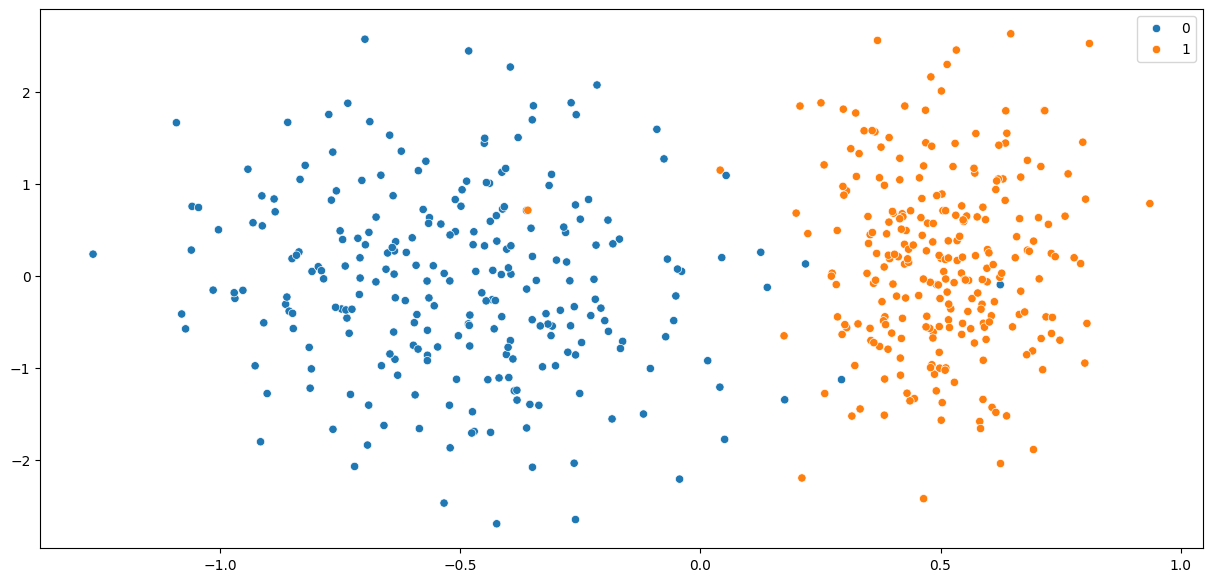

In [40]:
X, y = make_classification(
    n_samples = 500,
    n_features = 2,
    n_informative = 1,
    n_redundant = 0,
    n_classes = 2,
    n_clusters_per_class = 1,
    class_sep = 0.5,
    random_state = 42
)

plt.figure(figsize=(15, 7))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue = y)
plt.show()

In [41]:
class Perceptron:
    def __init__(self, lr, epochs):
        self.coef_ = None       # Weights for input features
        self.intercept_ = None  # Bias term
        self.lr = lr            # Learning rate
        self.epochs = epochs    # Number of training iterations

    def activation(self, fx):
        return 1 if fx > 0 else 0

    def fit(self, X_train, y_train_original):
        # Initialize weights randomly
        self.coef_ = np.random.randn(X_train.shape[1])
        self.intercept_ = 0

        # Training loop
        for _ in range(self.epochs):

            # Process training examples in random order
            for idx in np.random.permutation(X_train.shape[0]):

                # Calculate prediction using the internal 0/1 labels
                y_hat_internal = self.activation(np.dot(X_train[idx], self.coef_) + self.intercept_)

                # Parameters updation using geometric intuition formulas
                """
                    Derivation
                        new_co-ordinates_of_decision_boundry = decision_boundry_co-ordinates (- or +) co-ordinates_of_point
                        (w1, w2)new = (w1, w2)old [- or +] (x1, x2) [Weights]
                        (b1)new = (b1)old [- or +] (1) —→ always put 1  

                        generalization for [- or +]
                            (y_pred - y_actual)
                                if y_actual = 1 and y_pred = 0 —→ Missclassification - Decision boundry must increase its co-ordinate values
                                    [0 - 1] = -1 and with -= (in equation) —→ Addition
                                    [1 - 0] = 1 and with -= (in equation) —→ Subtraction
                """
                self.coef_ -= self.lr * (y_hat_internal - y_train[idx]) * X_train[idx]
                self.intercept_ -= self.lr * (y_hat_internal - y_train[idx]) * 1 # always put 1 because there is no term in 'x' to subtract —→ refer notes

    def predict(self, X_test):
        # Calculate weighted sum + bias
        ans = np.dot(X_test, self.coef_) + self.intercept_
        return np.where(ans >= 0, 1, 0) # Use >= 0 for the positive class (1) based on standard perceptron

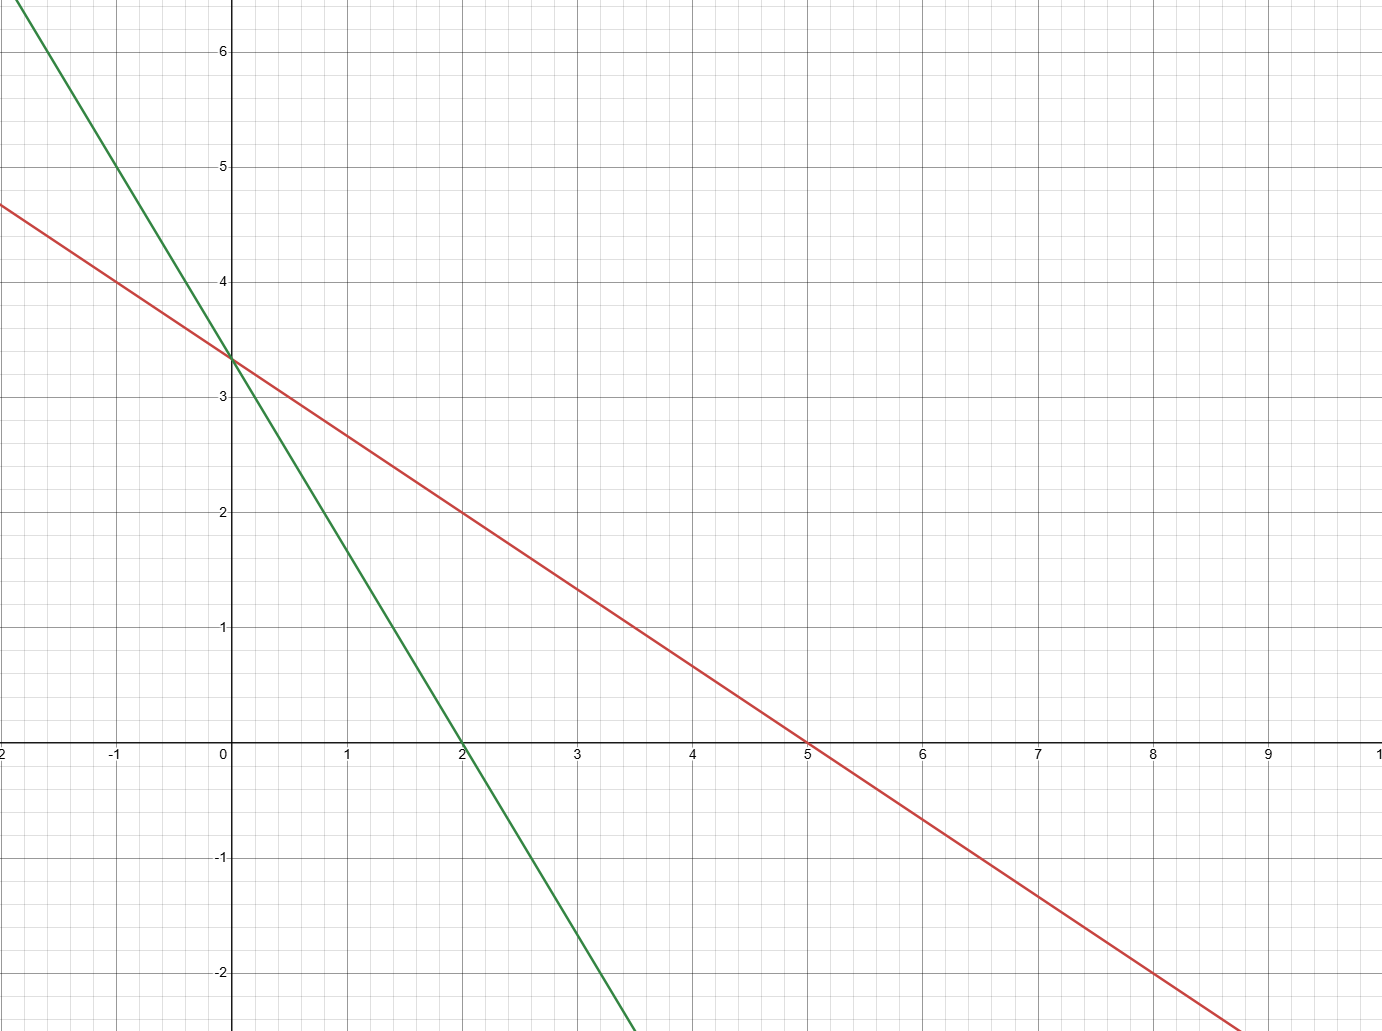

Observation → When you increase the co-ordinate of X (i.e weight corrosponding to 1st feature). It fixes at Y axis and the X value reduces (see the movement)

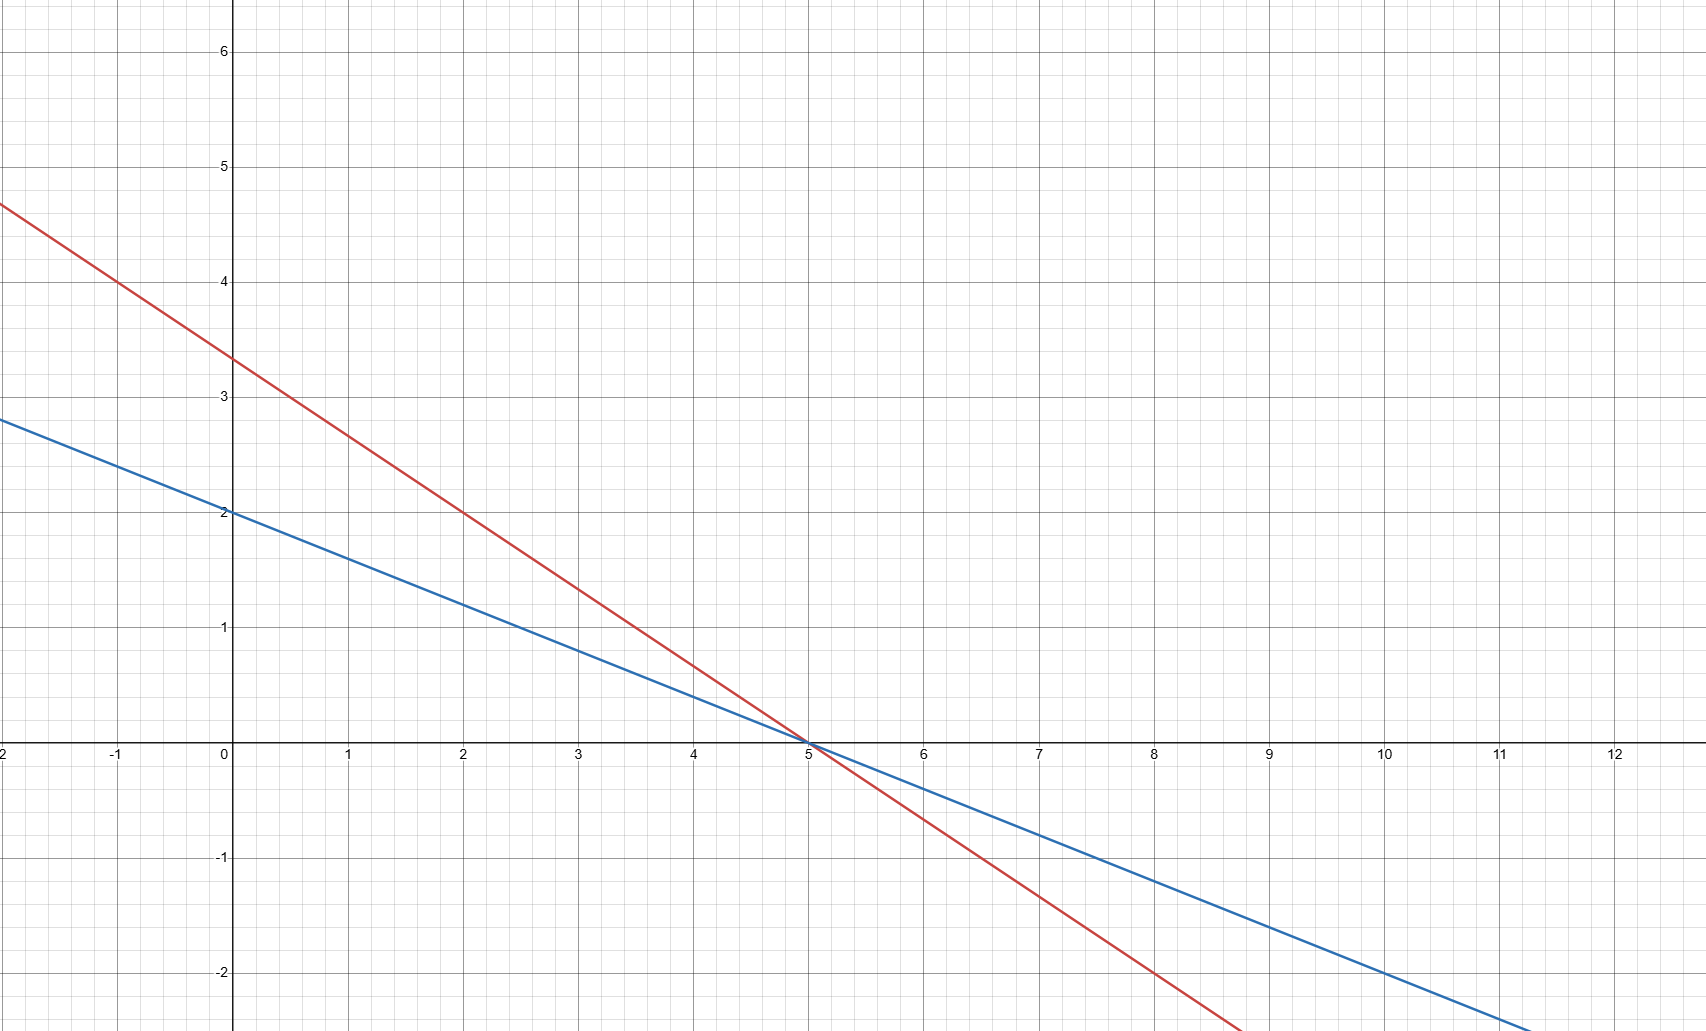

Observation → When you increase the co-ordinate of Y (i.e weight corrosponding to 2st feature). It fixes at X axis and the Y value reduces (see the movement)

Correcting the Missclassification in Red Decision Boundry to Green Decision Boundry by increasing the the values of co-ordinates of Decision Boundry

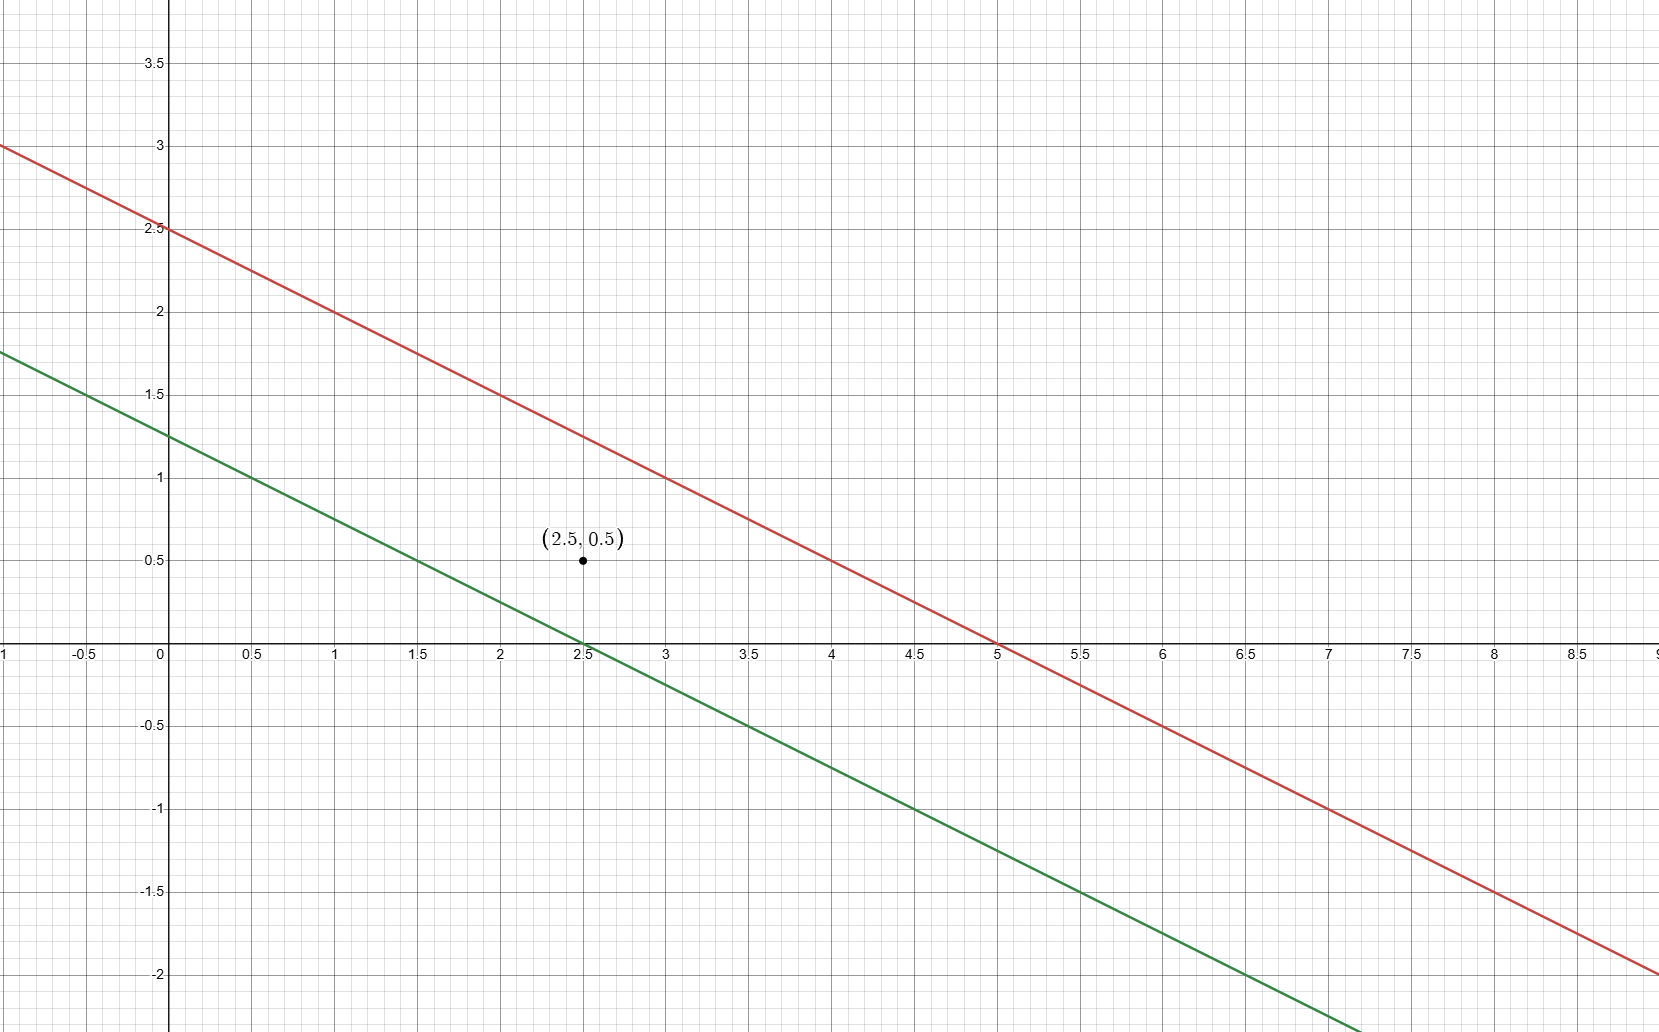

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [43]:
model = Perceptron(0.01, 250)
model.fit(X_train, y_train)

print(model.intercept_)
print(model.coef_)

-0.009999999999999997
[0.07315656 0.0115711 ]


In [44]:
f1_score(y_test, model.predict(X_test))

0.9896907216494846

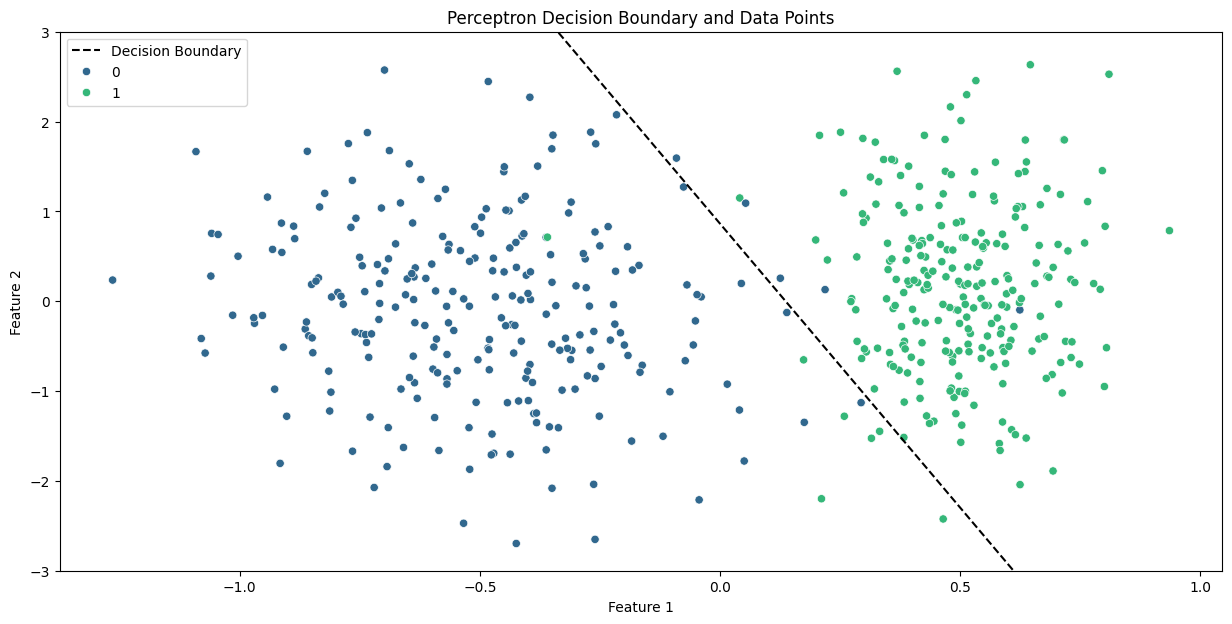

In [45]:
# Assuming X is your feature matrix and y is the target array
# Calculate the decision boundary
weight = -model.coef_[0] / model.coef_[1]
bias = -model.intercept_ / model.coef_[1]

# Create a range of values for the decision boundary plot
temp_x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# Decision boundary equation
temp_x2 = weight * temp_x1 + bias

# Plot the decision boundary
plt.figure(figsize=(15, 7))

# Plot decision boundary
plt.plot(temp_x1, temp_x2, 'k--', label='Decision Boundary')

# Plot the data points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full')

# Label the axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary and Data Points')

# Add a legend and show the plot
plt.ylim(-3, 3)
plt.legend()
plt.show()

<hr>

In [46]:
from sklearn.linear_model import Perceptron
model = Perceptron(
    penalty=None, # Regularization parameter l2' or 'l1' or None
    alpha=0.0001, # Regularization Coefficient
    fit_intercept=True, # Calculate the intercept or not
    max_iter=1000, # Number of Iterations for GD
    tol=1e-3, # The convergence threshold. If the diff of the loss between two consecutive epochs is less than tol, convergence is assumed.
    shuffle=True, # Whether or not the training data should be shuffled after each epoch
    verbose=1, # Training phase printing
    eta0=0.01, # Learning Rate
    n_jobs=-1,
    random_state=42,
    validation_fraction=0.1, # The proportion of training data to set aside as validation set for early stopping
    n_iter_no_change=5 # The number of iterations with no improvement to wait before early stopping
)

# How validation_fraction works: If the model's performance on the validation set doesn't improve for a certain number of epochs (set by n_iter_no_change), training stops early to prevent overfitting.

In [47]:
model.fit(X_train, y_train)

-- Epoch 1
Norm: 0.06, NNZs: 2, Bias: 0.000000, T: 400, Avg. loss: 0.000308, Objective: 0.000308
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 0.06, NNZs: 2, Bias: -0.010000, T: 800, Avg. loss: 0.000319, Objective: 0.000319
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 0.06, NNZs: 2, Bias: -0.010000, T: 1200, Avg. loss: 0.000394, Objective: 0.000394
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 0.06, NNZs: 2, Bias: -0.010000, T: 1600, Avg. loss: 0.000306, Objective: 0.000306
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 0.08, NNZs: 2, Bias: -0.020000, T: 2000, Avg. loss: 0.000337, Objective: 0.000337
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 0.08, NNZs: 2, Bias: -0.010000, T: 2400, Avg. loss: 0.000471, Objective: 0.000471
Total training time: 0.00 seconds.
Convergence after 6 epochs took 0.00 seconds


,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",1
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [48]:
print(model.coef_)
print(model.intercept_)

[[0.08201616 0.00853332]]
[-0.01]


In [49]:
f1_score(y_test, model.predict(X_test))

1.0

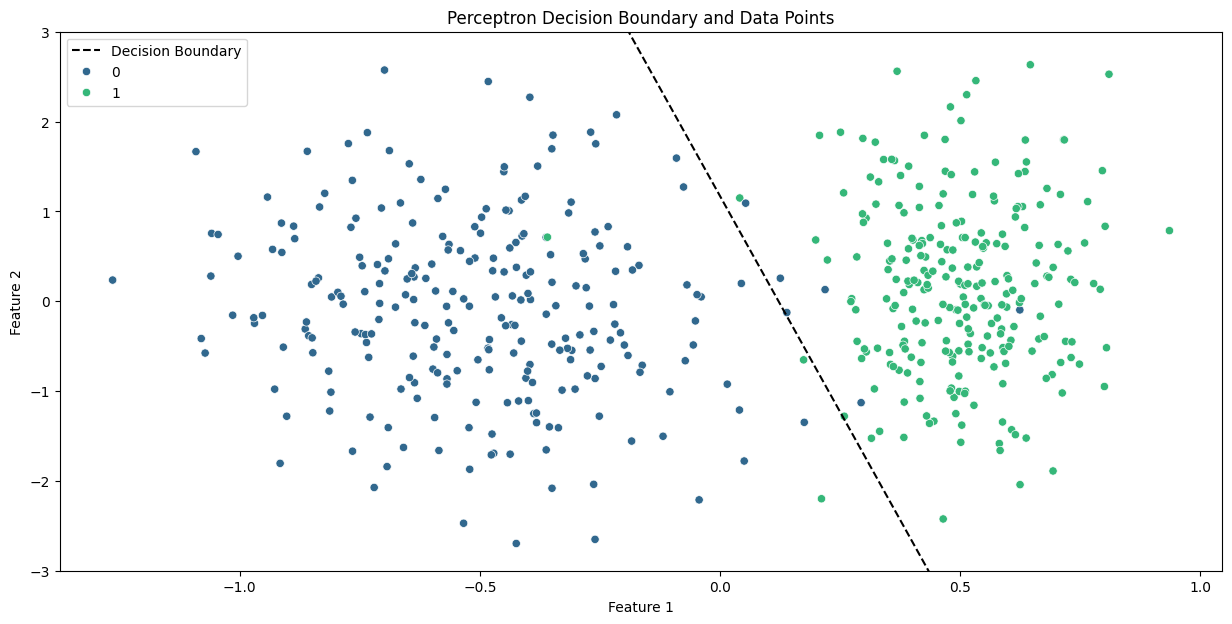

In [50]:
# Assuming X is your feature matrix and y is the target array
# Calculate the decision boundary
weight = -model.coef_[0][0] / model.coef_[0][1]
bias = -model.intercept_ / model.coef_[0][1]

# Create a range of values for the decision boundary plot
temp_x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 500)

# Decision boundary equation
temp_x2 = weight * temp_x1 + bias

# Plot the decision boundary
plt.figure(figsize=(15, 7))

# Plot decision boundary
plt.plot(temp_x1, temp_x2, 'k--', label='Decision Boundary')

# Plot the data points
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', legend='full')

# Label the axes
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary and Data Points')

# Add a legend and show the plot
plt.ylim(-3, 3)
plt.legend()
plt.show()

In [51]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss="perceptron", penalty=None,
                        learning_rate="constant", eta0=0.01, random_state=42)
sgd_clf.fit(X_train, y_train) # loss = 'perceptron' —→ Hinge Loss
assert (sgd_clf.coef_ == model.coef_).all()
assert (sgd_clf.intercept_ == model.intercept_).all()
print("All Good")

All Good
